C:\Users\ZBooK\AppData\Local\Temp\ipykernel_24888\1242108292.py:3: DtypeWarning: Columns (7,25,50,173,174,175,176) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Lyon_dataset.csv")


['numero_dpe', 'date_derniere_modification_dpe', 'date_visite_diagnostiqueur', 'date_etablissement_dpe', 'date_reception_dpe', 'date_fin_validite_dpe', 'numero_dpe_remplace', 'numero_dpe_immeuble_associe', 'id_rnb', 'numero_rpls_logement', 'numero_immatriculation_copropriete', 'modele_dpe', 'version_dpe', 'methode_application_dpe', 'etiquette_dpe', 'etiquette_ges', 'type_batiment', 'annee_construction', 'periode_construction', 'type_installation_chauffage', 'type_installation_ecs', 'hauteur_sous_plafond', 'nombre_appartement', 'nombre_niveau_immeuble', 'nombre_niveau_logement', 'typologie_logement', 'appartement_non_visite', 'surface_habitable_immeuble', 'surface_habitable_logement', 'surface_tertiaire_immeuble', 'classe_inertie_batiment', 'classe_altitude', 'zone_climatique', 'adresse_ban', 'numero_voie_ban', 'nom_rue_ban', 'nom_commune_ban', 'code_postal_ban', 'code_insee_ban', 'code_departement_ban', 'code_region_ban', 'identifiant_ban', 'coordonnee_cartographique_x_ban', 'coordonne

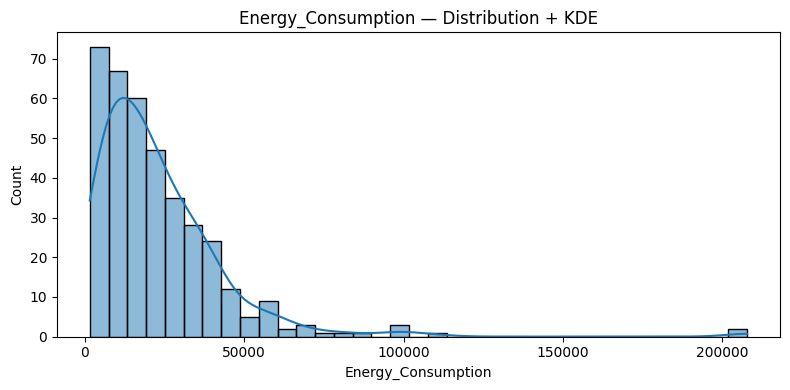

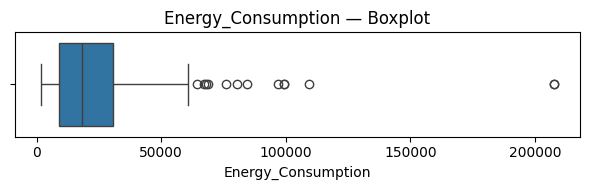

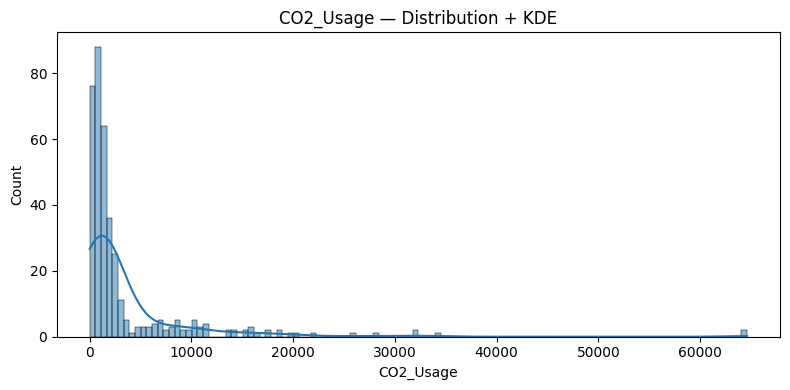

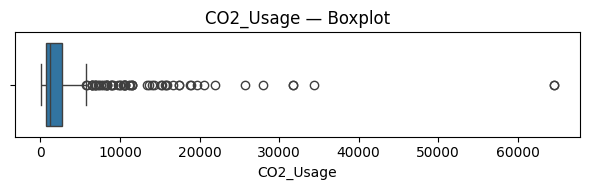

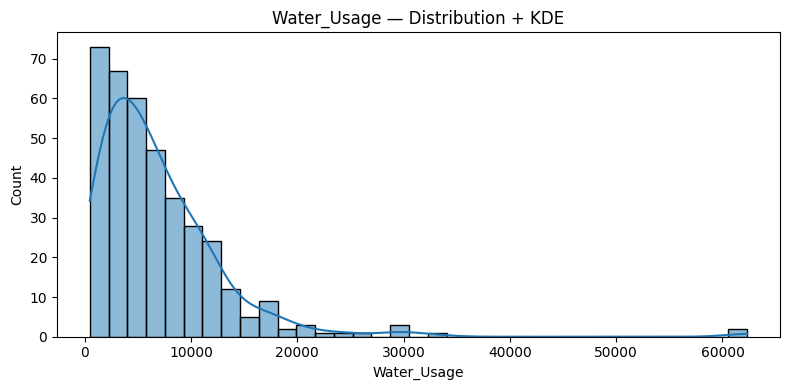

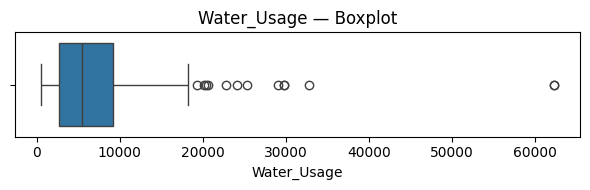

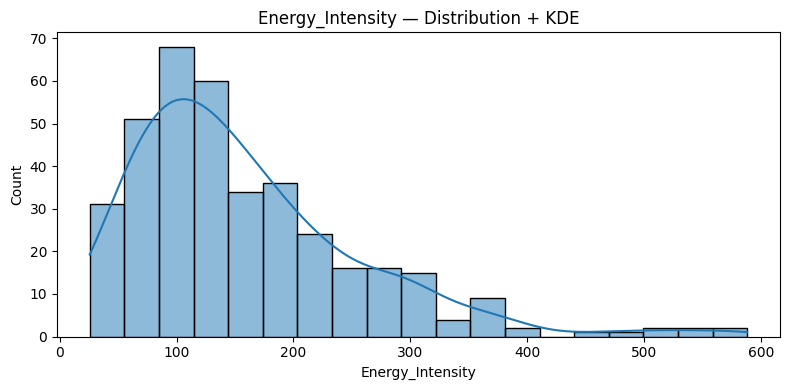

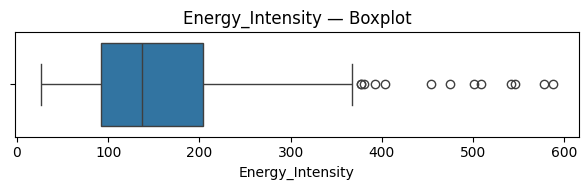

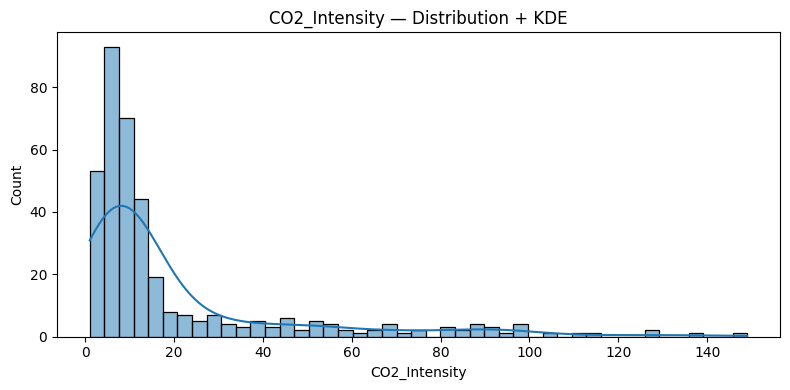

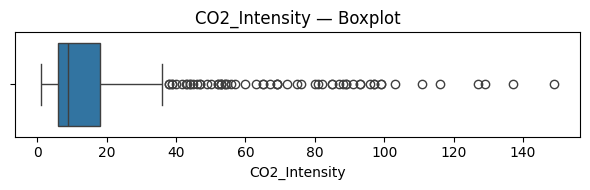


===== CORRELATION MATRIX =====
                    Energy_Consumption  CO2_Usage  Water_Usage  \
Energy_Consumption            1.000000   0.906948     1.000000   
CO2_Usage                     0.906948   1.000000     0.906948   
Water_Usage                   1.000000   0.906948     1.000000   
Energy_Intensity              0.471044   0.397360     0.471044   
CO2_Intensity                 0.602196   0.727863     0.602196   

                    Energy_Intensity  CO2_Intensity  
Energy_Consumption          0.471044       0.602196  
CO2_Usage                   0.397360       0.727863  
Water_Usage                 0.471044       0.602196  
Energy_Intensity            1.000000       0.699056  
CO2_Intensity               0.699056       1.000000  


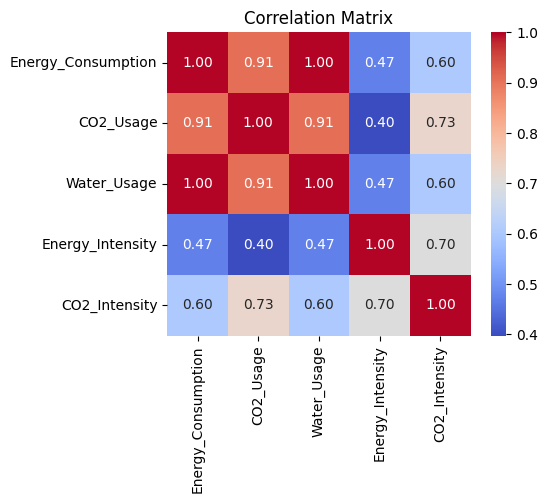

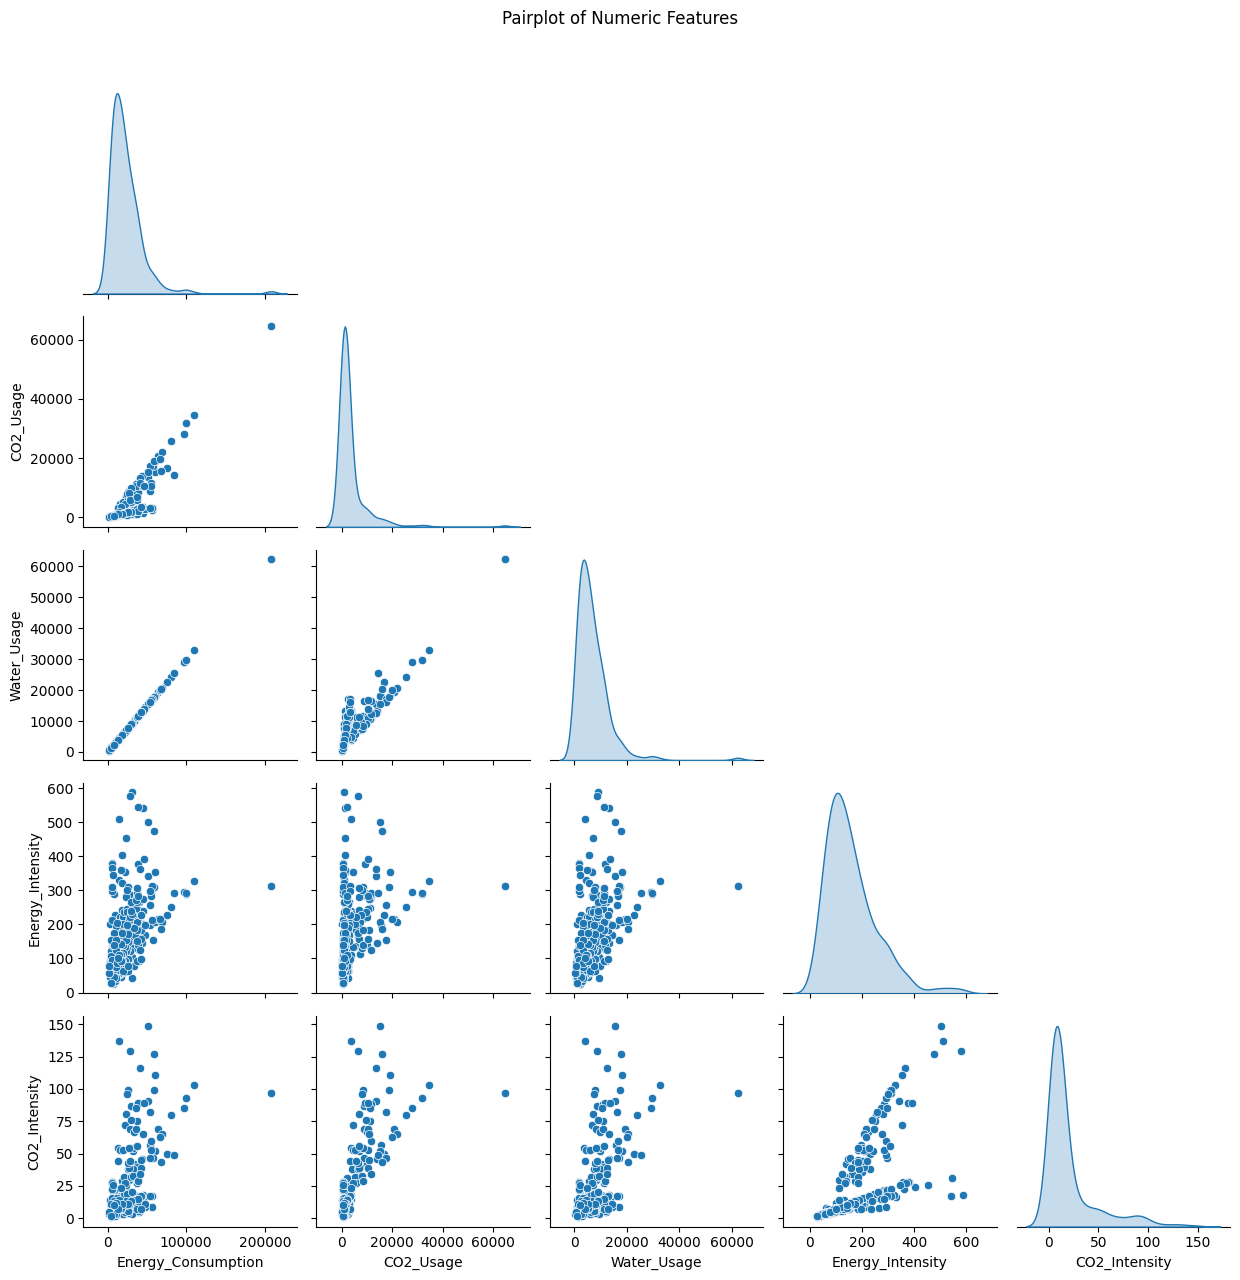

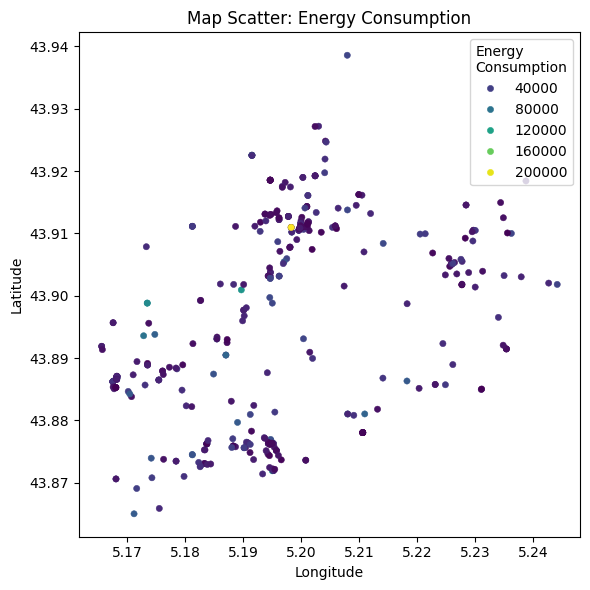

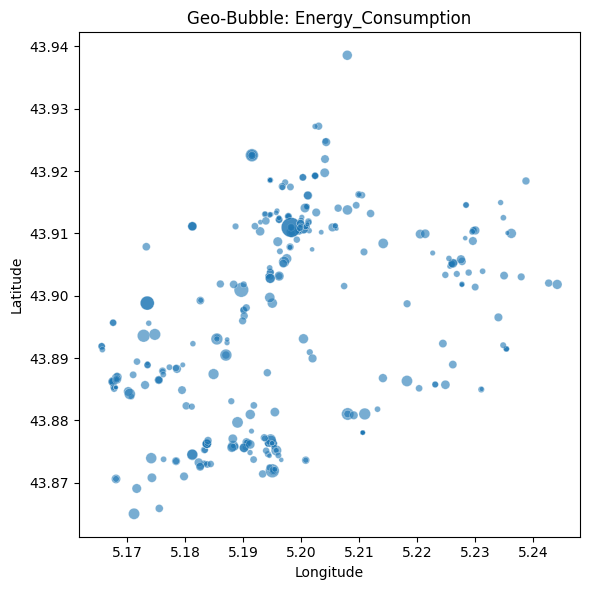

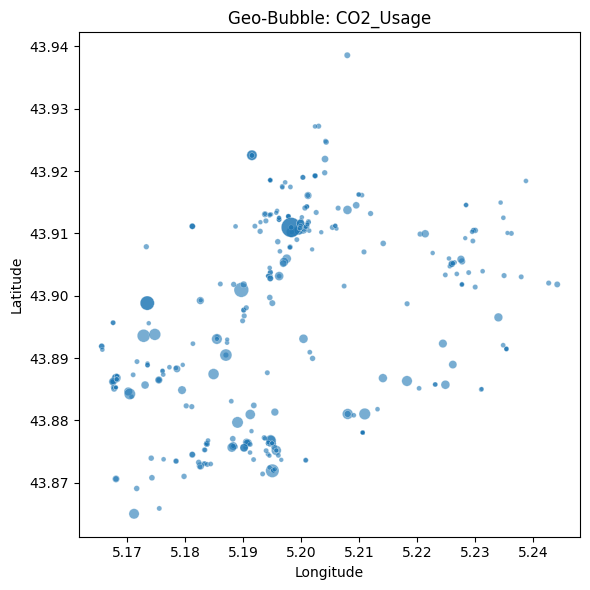

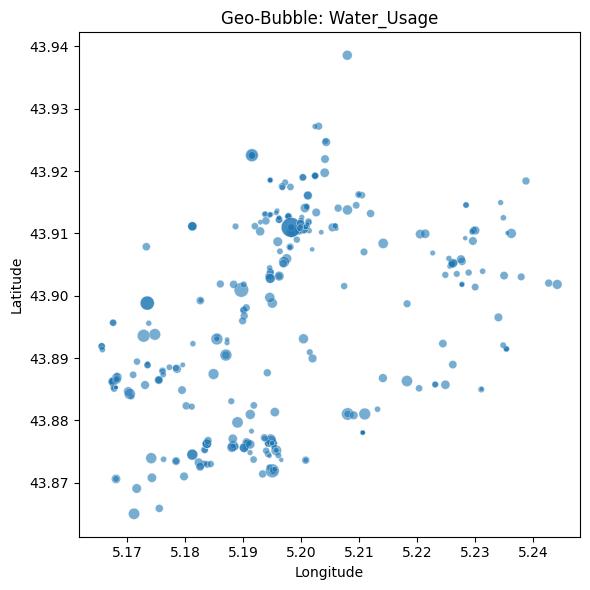

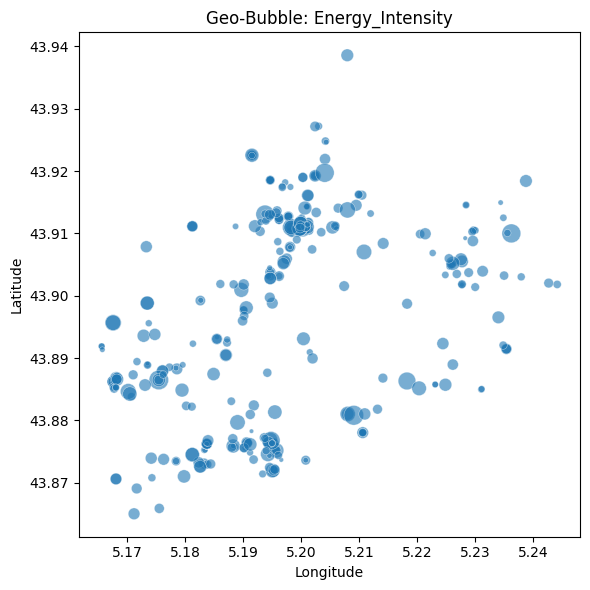

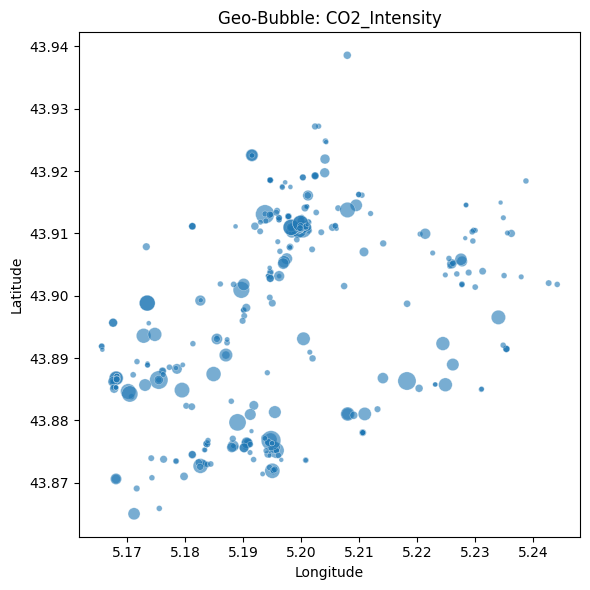

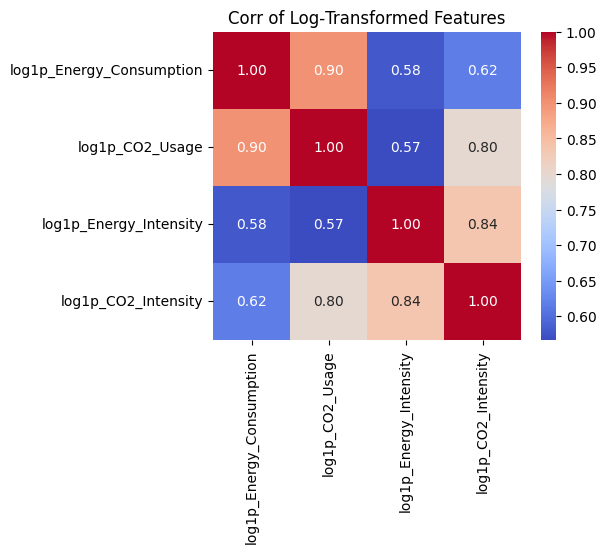

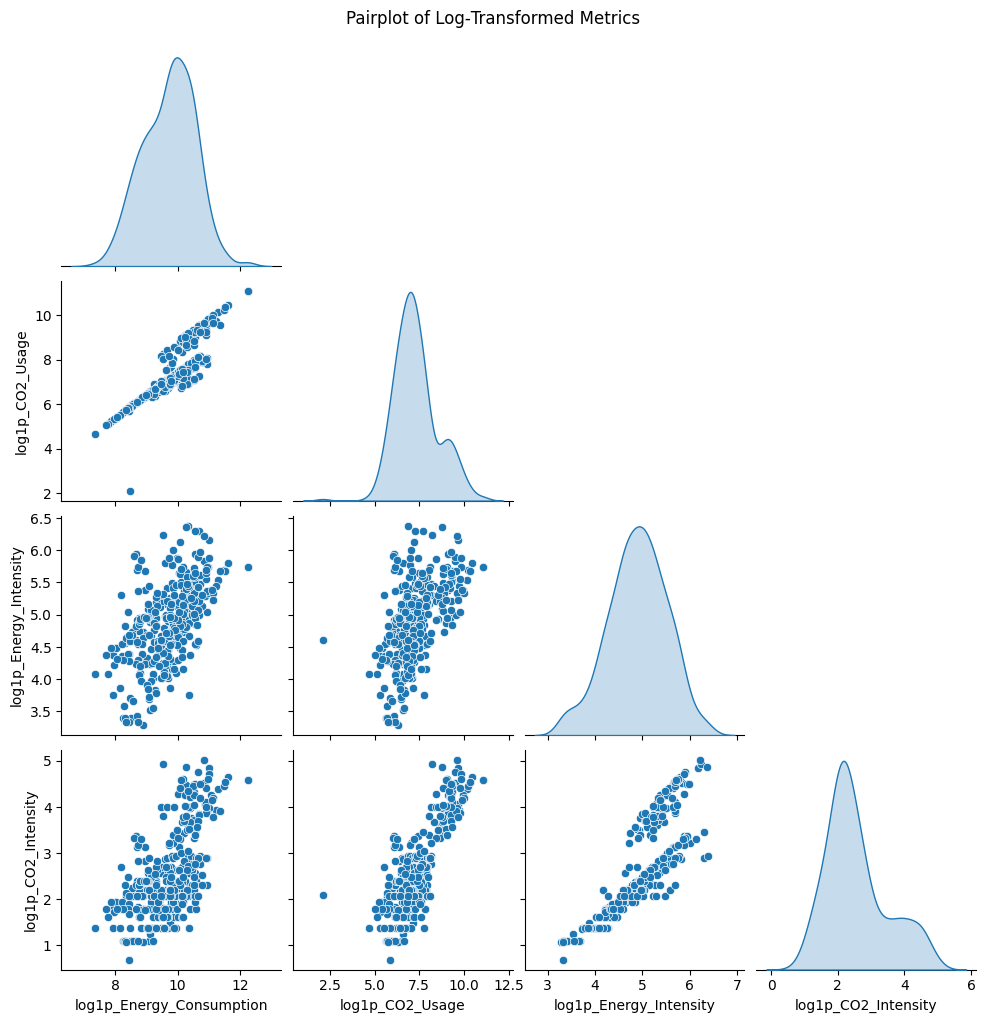

Explained variance ratios: [0.78820897 0.15236911]


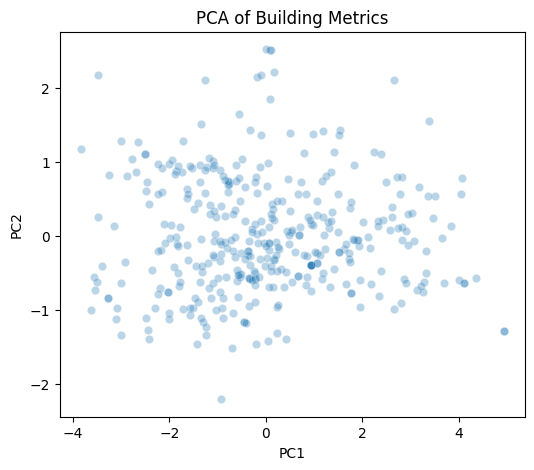

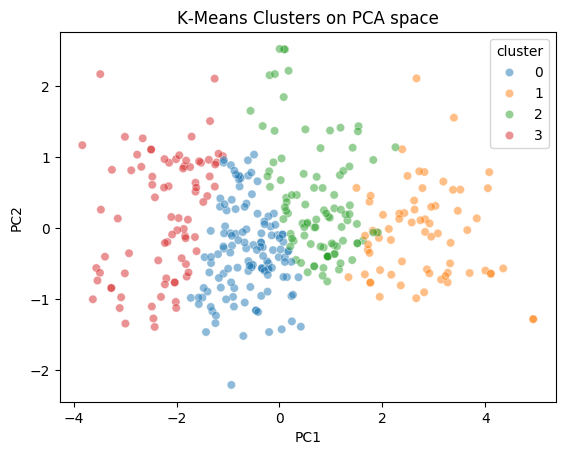

In [29]:
import pandas as pd
import numpy as np
df = pd.read_csv("Lyon_dataset.csv")

df.head()
print(df.columns.tolist())
from pyproj import Transformer

def convert_coordinates(df):
    transformer = Transformer.from_crs("EPSG:2154", "EPSG:4326", always_xy=True)
    lon, lat = transformer.transform(df["coordonnee_cartographique_x_ban"].values,
                                     df["coordonnee_cartographique_y_ban"].values)
    df["longitude"] = lon
    df["latitude"] = lat
    return df

df = convert_coordinates(df)
df = df.rename(columns={
    "numero_dpe": "building_id",
    "conso_5 usages_ef": "Energy_Consumption",
    "emission_ges_5_usages": "CO2_Usage"
})

df["Water_Usage"] = df["Energy_Consumption"] * 0.3  

df["Energy_Intensity"] = df["conso_5 usages_par_m2_ef"]
df["CO2_Intensity"] = df["emission_ges_5_usages par_m2"]
# 1. Rename the raw DPE columns
df = df.rename(columns={
    "etiquette_dpe": "true_energy_label",
    "etiquette_ges":  "true_ges_label"
})

# 2. Select only the ID + the two true‑label columns
label_cols = ["building_id", "true_energy_label", "true_ges_label"]
df_labels = df[label_cols]
final_cols = [
    #–– Primary key & location ––
    "building_id",
    "latitude", "longitude",

    #–– Core performance metrics ––
    "Energy_Consumption", "CO2_Usage", "Water_Usage",
    "Energy_Intensity",   "CO2_Intensity",

    #–– Official DPE labels ––
    "true_energy_label",  "true_ges_label",

    #–– BAN address fields (normalized) ––
    "adresse_ban",         # full standardized address
    "numero_voie_ban",     # street number
    "nom_rue_ban",         # street name
    "code_postal_ban",     # postal code
    "nom_commune_ban",     # commune name
    "identifiant_ban",     # BAN address ID

    #–– Raw-fallback address fields ––
    "adresse_brut",
    "nom_commune_brut",
    "code_postal_brut",

    #–– Basic building attributes for filters ––
    "annee_construction",
    "surface_habitable_immeuble",
    # you could also add:
    # "type_batiment", "typologie_logement",
    # "nombre_appartement", "nombre_niveau_immeuble",
    # "complement_adresse_batiment", etc.
]

df = df[final_cols].dropna()

df = df[final_cols].dropna()


# Save as clean dataset
df.to_csv("reduced_lyon_buildings.csv", index=False)

print(" Clean dataset saved.")

# eda_buildings_inline.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# If you’re in a Jupyter notebook, enable inline plotting:
# %matplotlib inline

# 1. Load the data
df = pd.read_csv("reduced_gordes_buildings.csv")

# 2. Quick overview
print("===== DATA INFO =====")
df.info()
print("\n===== MISSING VALUES =====")
print(df.isnull().sum())
print("\n===== DESCRIPTIVE STATISTICS =====")
print(df.describe().T)

# Identify numeric features (exclude ID & coords)
numeric_cols = [
    "Energy_Consumption",
    "CO2_Usage",
    "Water_Usage",
    "Energy_Intensity",
    "CO2_Intensity"
]

# 3. Univariate distributions
for col in numeric_cols:
    # Distribution + KDE
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} — Distribution + KDE")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    # Boxplot
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f"{col} — Boxplot")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

# 4. Correlation matrix
corr = df[numeric_cols].corr()
print("\n===== CORRELATION MATRIX =====")
print(corr)

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# 5. Pairwise scatterplots
sns.pairplot(df[numeric_cols], diag_kind="kde", corner=True)
plt.suptitle("Pairplot of Numeric Features", y=1.02)
plt.tight_layout()
plt.show()

# 6. Geographic scatter (colored by Energy_Consumption)
plt.figure(figsize=(6,6))
sns.scatterplot(
    x=df["longitude"], y=df["latitude"],
    hue=df["Energy_Consumption"],
    palette="viridis", edgecolor=None, s=20
)
plt.title("Map Scatter: Energy Consumption")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Energy\nConsumption", loc="upper right")
plt.tight_layout()
plt.show()

# 7. Geographic bubble plots (sized by each feature)
for col in numeric_cols:
    plt.figure(figsize=(6,6))
    sns.scatterplot(
        x=df["longitude"], y=df["latitude"],
        size=df[col], sizes=(10,200), alpha=0.6, legend=False
    )
    plt.title(f"Geo‑Bubble: {col}")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.tight_layout()
    plt.show()

import numpy as np
import pandas as pd

# assume df is your DataFrame from before
df2 = df.drop(columns=["Water_Usage"]).copy()

# Choose which columns to log‐transform
to_log = ["Energy_Consumption", "CO2_Usage", "Energy_Intensity", "CO2_Intensity"]

for col in to_log:
    df2[f"log1p_{col}"] = np.log1p(df2[col])
import seaborn as sns
import matplotlib.pyplot as plt

log_cols = [f"log1p_{c}" for c in to_log]
corr2 = df2[log_cols].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr2, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Corr of Log‑Transformed Features")
plt.show()
sns.pairplot(df2[log_cols], diag_kind="kde", corner=True)
plt.suptitle("Pairplot of Log‑Transformed Metrics", y=1.02)
plt.show()
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df2[log_cols].values
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

print("Explained variance ratios:", pca.explained_variance_ratio_)

# attach back to df2 for plotting
df2["PC1"], df2["PC2"] = pcs[:,0], pcs[:,1]

plt.figure(figsize=(6,5))
sns.scatterplot(x="PC1", y="PC2", data=df2, alpha=0.3)
plt.title("PCA of Building Metrics")
plt.show()

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
df2["cluster"] = kmeans.fit_predict(X_scaled)

sns.scatterplot(x="PC1", y="PC2", hue="cluster", data=df2, palette="tab10", alpha=0.5)
plt.title("K‑Means Clusters on PCA space")
plt.show()

# Ensure df2 contains the log-transformed columns
log_cols = [f"log1p_{c}" for c in ["Energy_Consumption", "CO2_Usage", "Energy_Intensity", "CO2_Intensity"]]

# Merge the log-transformed features back to the original dataset
df_full = df.copy()
for col in log_cols:
    df_full[col] = df2[col]


Clean dataset saved.
===== DATA INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   building_id                 374 non-null    object 
 1   latitude                    374 non-null    float64
 2   longitude                   374 non-null    float64
 3   Energy_Consumption          374 non-null    float64
 4   CO2_Usage                   374 non-null    float64
 5   Water_Usage                 374 non-null    float64
 6   Energy_Intensity            374 non-null    float64
 7   CO2_Intensity               374 non-null    float64
 8   true_energy_label           374 non-null    object 
 9   true_ges_label              374 non-null    object 
 10  adresse_ban                 374 non-null    object 
 11  numero_voie_ban             268 non-null    object 
 12  nom_rue_ban                 315 non-null    objec

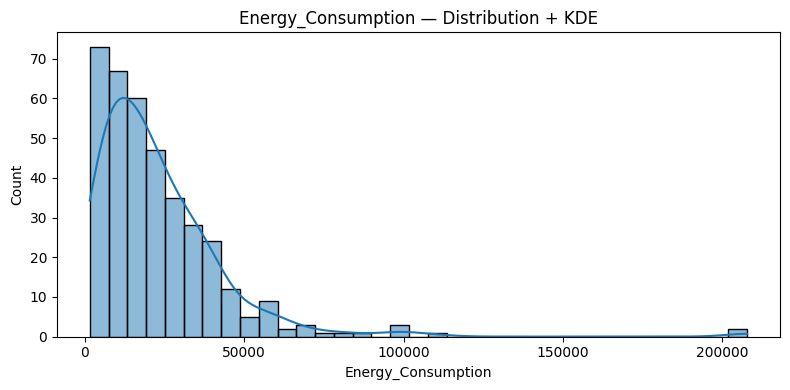

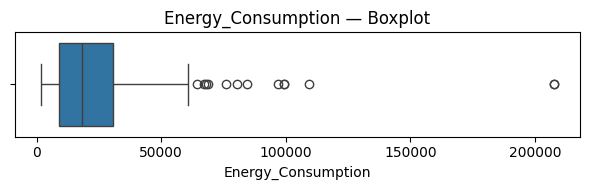

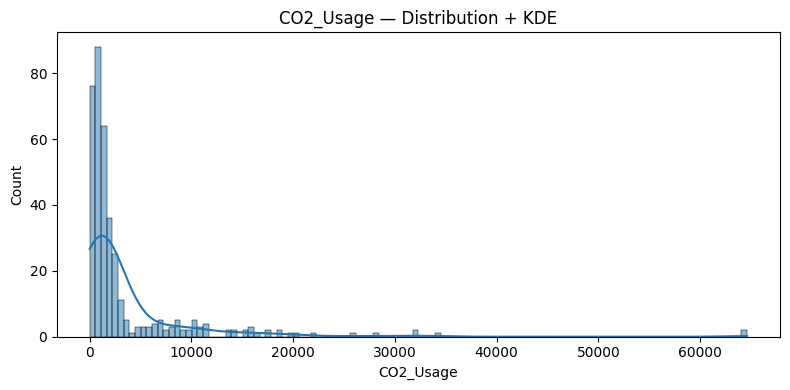

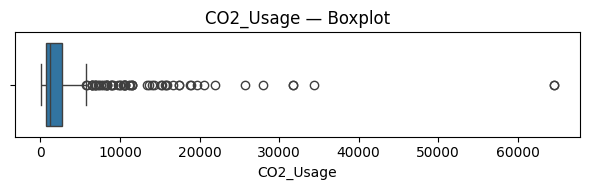

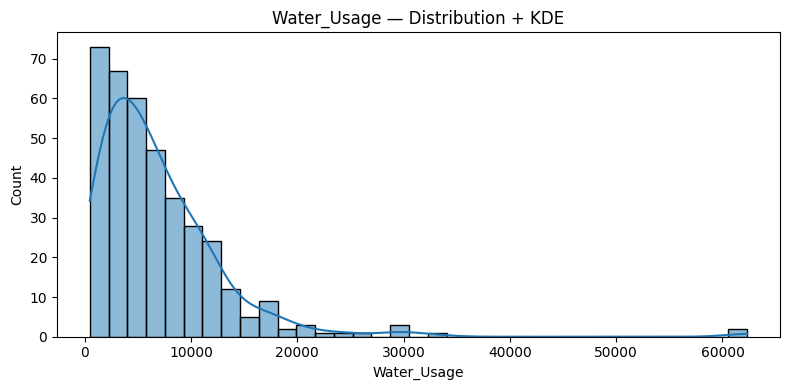

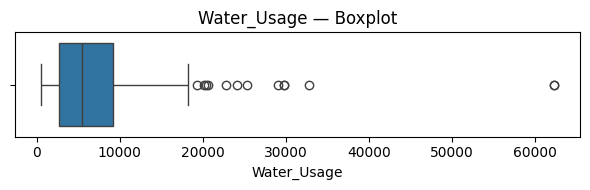

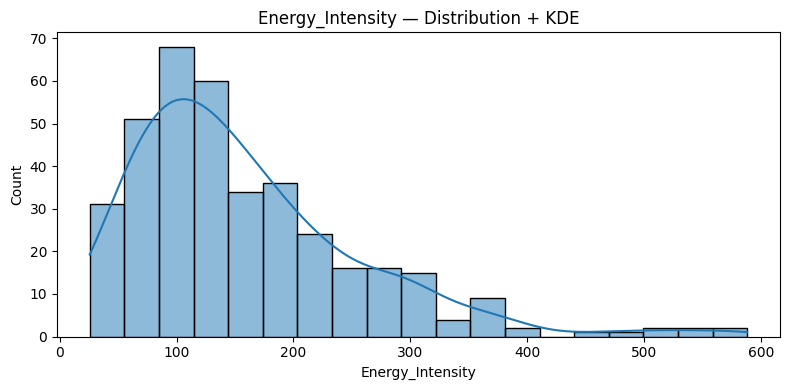

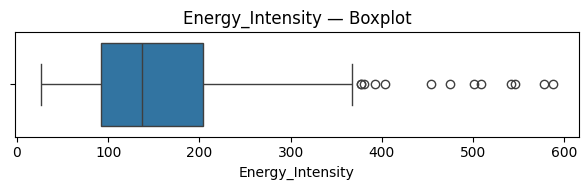

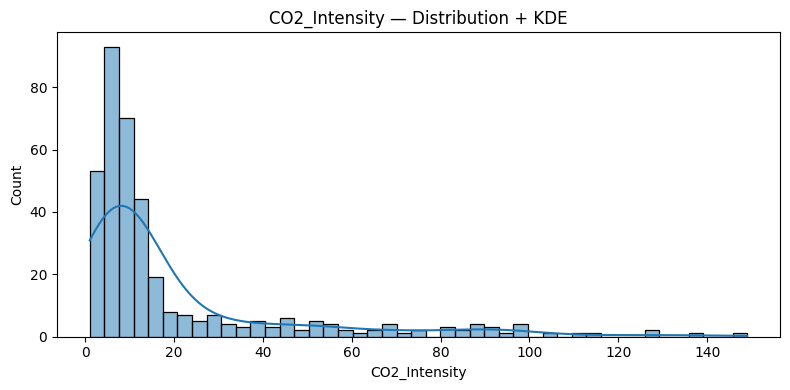

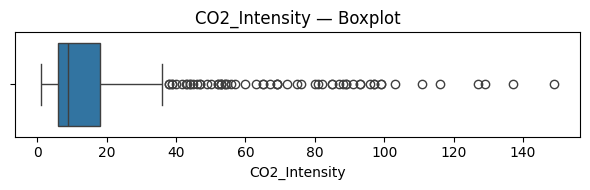


===== CORRELATION MATRIX =====
                    Energy_Consumption  CO2_Usage  Water_Usage  \
Energy_Consumption            1.000000   0.906948     1.000000   
CO2_Usage                     0.906948   1.000000     0.906948   
Water_Usage                   1.000000   0.906948     1.000000   
Energy_Intensity              0.471044   0.397360     0.471044   
CO2_Intensity                 0.602196   0.727863     0.602196   

                    Energy_Intensity  CO2_Intensity  
Energy_Consumption          0.471044       0.602196  
CO2_Usage                   0.397360       0.727863  
Water_Usage                 0.471044       0.602196  
Energy_Intensity            1.000000       0.699056  
CO2_Intensity               0.699056       1.000000  


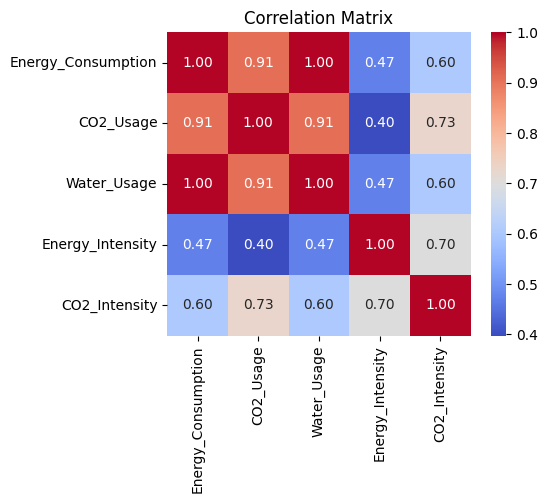

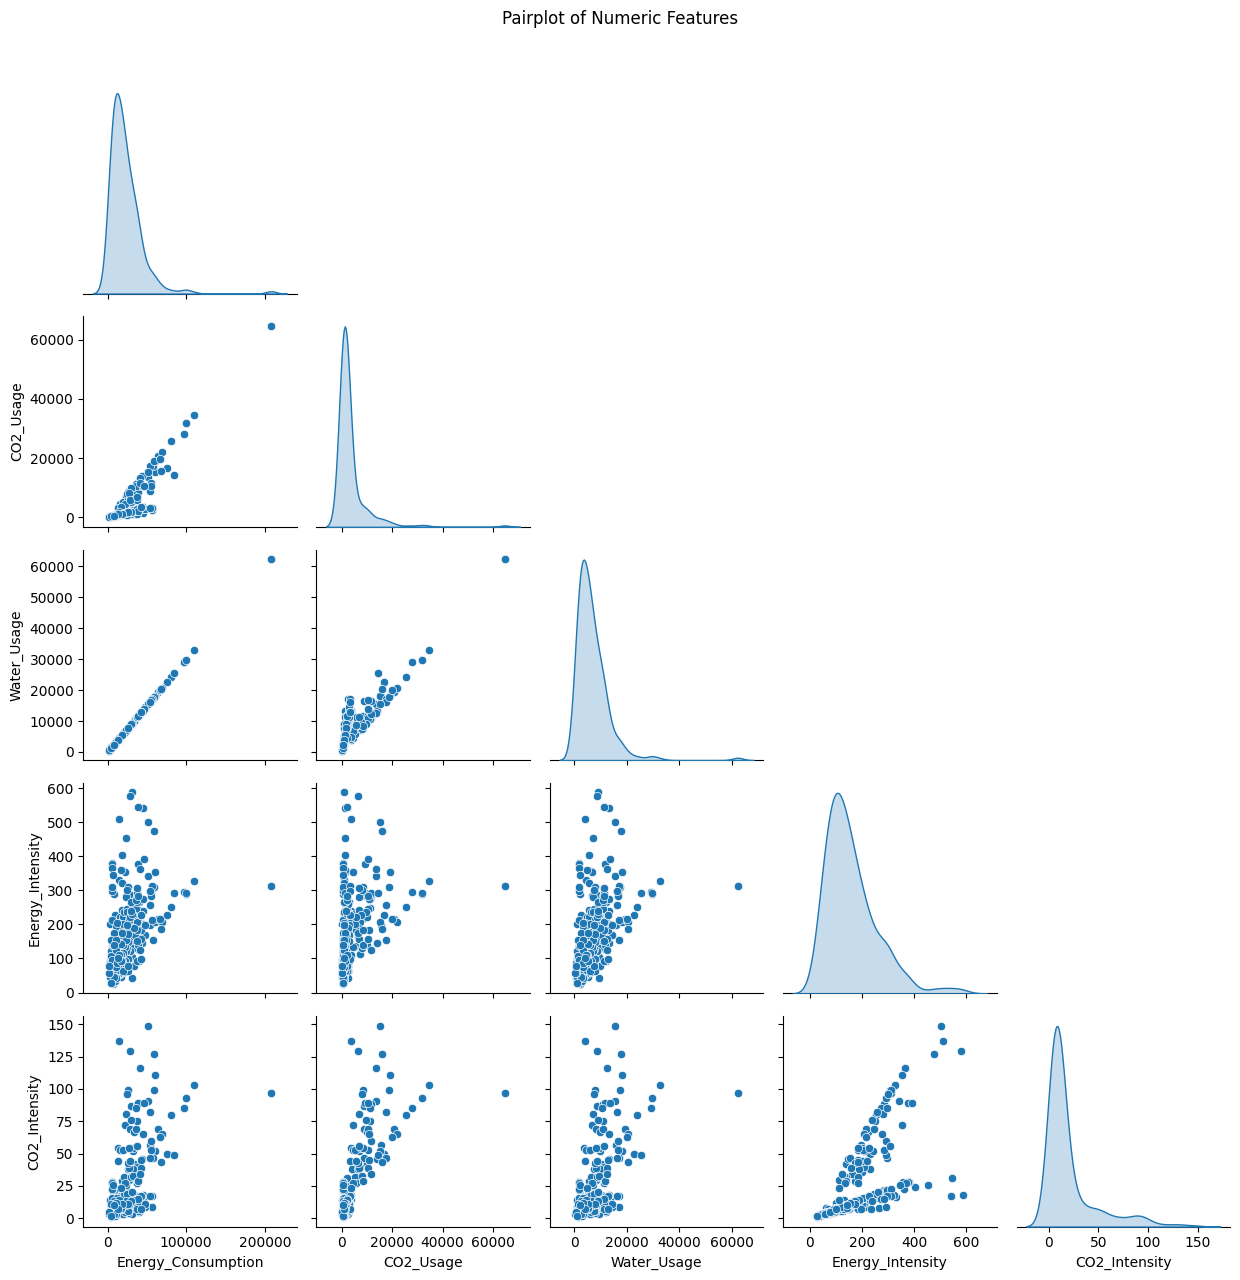

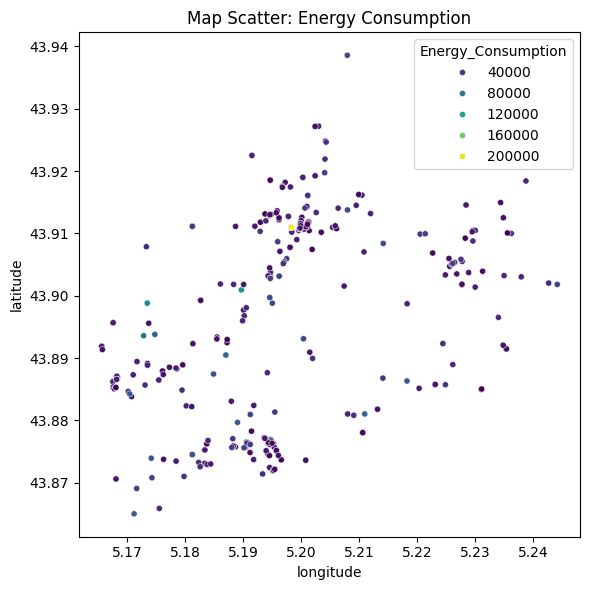

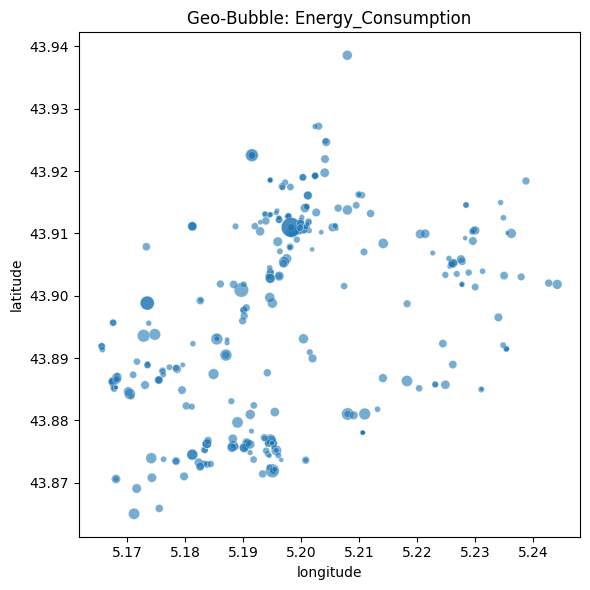

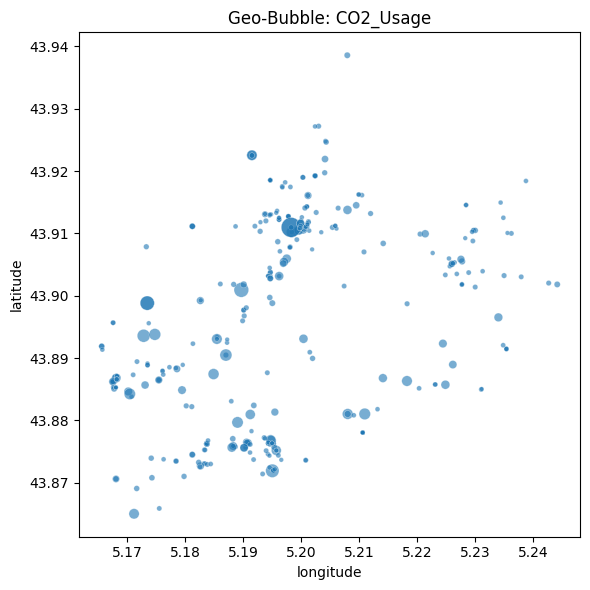

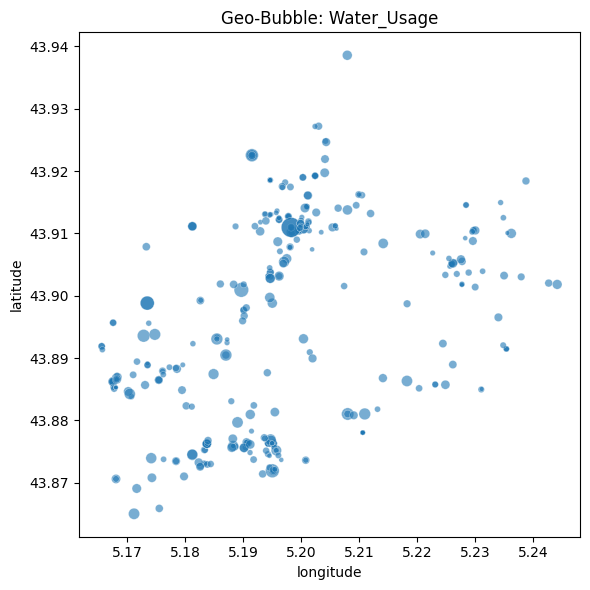

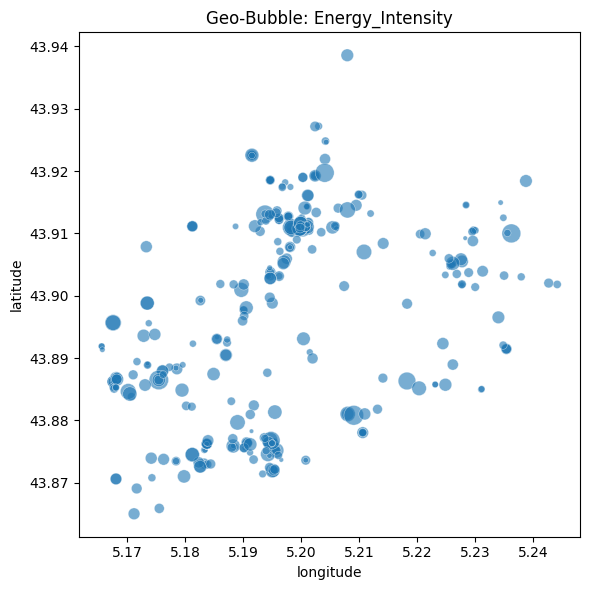

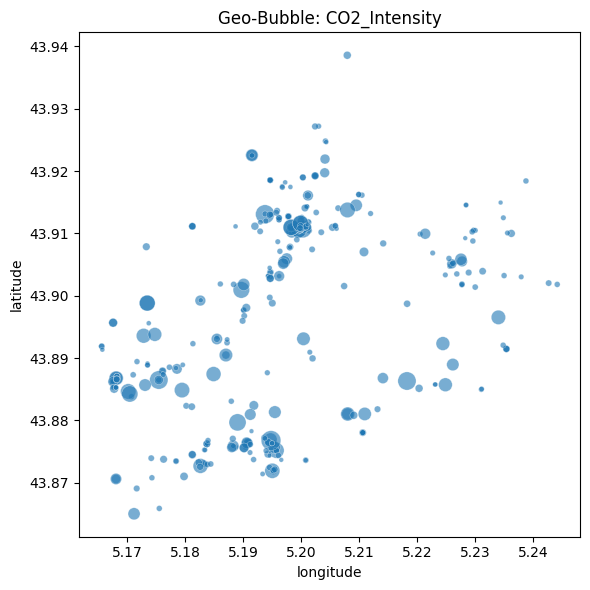

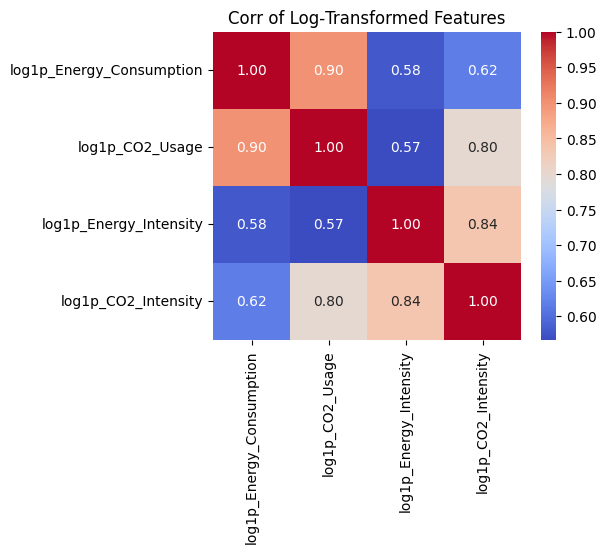

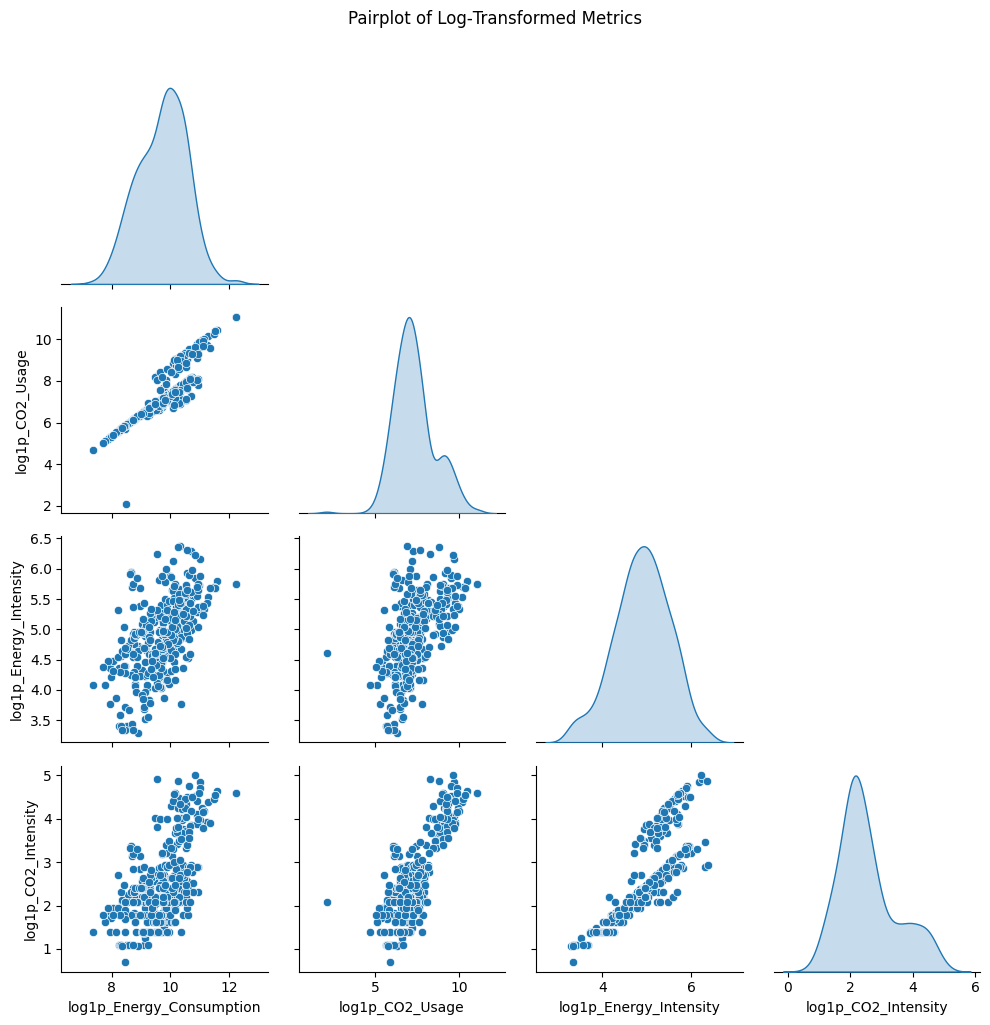

Explained variance ratios: [0.78820897 0.15236911]


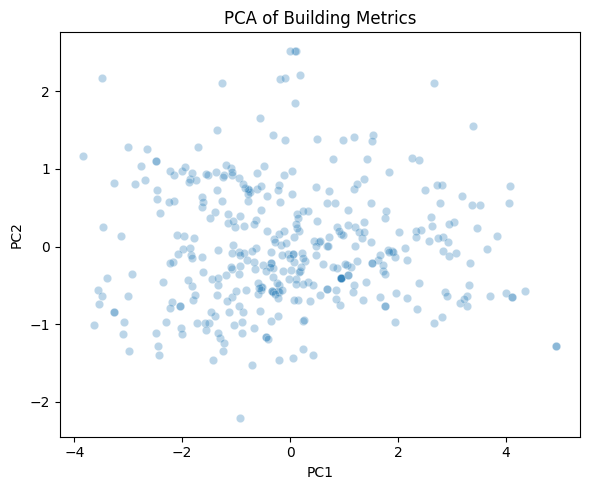

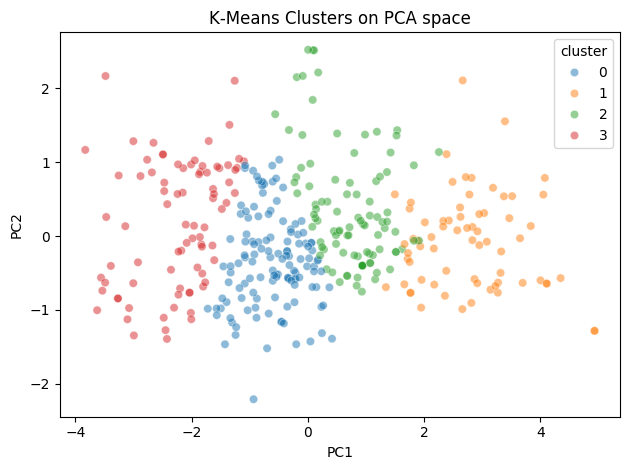

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyproj import Transformer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load data
df = pd.read_csv("gordes.csv")

# Convert coordinates
def convert_coordinates(df):
    transformer = Transformer.from_crs("EPSG:2154", "EPSG:4326", always_xy=True)
    lon, lat = transformer.transform(df["coordonnee_cartographique_x_ban"].values,
                                     df["coordonnee_cartographique_y_ban"].values)
    df["longitude"] = lon
    df["latitude"] = lat
    return df

df = convert_coordinates(df)

# Rename and engineer features
df = df.rename(columns={
    "numero_dpe": "building_id",
    "conso_5 usages_ef": "Energy_Consumption",
    "emission_ges_5_usages": "CO2_Usage",
    "etiquette_dpe": "true_energy_label",
    "etiquette_ges": "true_ges_label"
})

df["Water_Usage"] = df["Energy_Consumption"] * 0.3  
df["Energy_Intensity"] = df["conso_5 usages_par_m2_ef"]
df["CO2_Intensity"] = df["emission_ges_5_usages par_m2"]

final_cols = [
    #–– Primary key & location ––
    "building_id",
    "latitude", "longitude",

    #–– Core performance metrics ––
    "Energy_Consumption", "CO2_Usage", "Water_Usage",
    "Energy_Intensity",   "CO2_Intensity",

    #–– Official DPE labels ––
    "true_energy_label",  "true_ges_label",

    #–– BAN address fields (normalized) ––
    "adresse_ban",         # full standardized address
    "numero_voie_ban",     # street number
    "nom_rue_ban",         # street name
    "code_postal_ban",     # postal code
    "nom_commune_ban",     # commune name
    "identifiant_ban",     # BAN address ID

    #–– Raw-fallback address fields ––
    "adresse_brut",
    "nom_commune_brut",
    "code_postal_brut",

    #–– Basic building attributes for filters ––
    "annee_construction",
    "surface_habitable_immeuble",
    # you could also add:
    # "type_batiment", "typologie_logement",
    # "nombre_appartement", "nombre_niveau_immeuble",
    # "complement_adresse_batiment", etc.
]

required = [
  "building_id","latitude","longitude",
  "Energy_Consumption","CO2_Usage","Water_Usage",
  "Energy_Intensity","CO2_Intensity"
]

# select & only drop rows missing those essentials
df = df[final_cols].dropna(subset=required)

# Save cleaned dataset
df.to_csv("reduced_gordes_buildings.csv", index=False)
print("Clean dataset saved.")

# Reload for analysis
df = pd.read_csv("reduced_gordes_buildings.csv")

# Quick overview
print("===== DATA INFO =====")
df.info()
print("\n===== MISSING VALUES =====")
print(df.isnull().sum())
print("\n===== DESCRIPTIVE STATISTICS =====")
print(df.describe().T)

# Numeric features
numeric_cols = [
    "Energy_Consumption", "CO2_Usage", "Water_Usage",
    "Energy_Intensity", "CO2_Intensity"
]

# Univariate analysis
for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} — Distribution + KDE")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f"{col} — Boxplot")
    plt.tight_layout()
    plt.show()

# Correlation matrix
corr = df[numeric_cols].corr()
print("\n===== CORRELATION MATRIX =====")
print(corr)
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# Pairwise scatterplots
sns.pairplot(df[numeric_cols], diag_kind="kde", corner=True)
plt.suptitle("Pairplot of Numeric Features", y=1.02)
plt.tight_layout()
plt.show()

# Geographic scatter
plt.figure(figsize=(6,6))
sns.scatterplot(x=df["longitude"], y=df["latitude"], hue=df["Energy_Consumption"], palette="viridis", s=20)
plt.title("Map Scatter: Energy Consumption")
plt.tight_layout()
plt.show()

# Geo‑bubble plots
for col in numeric_cols:
    plt.figure(figsize=(6,6))
    sns.scatterplot(x=df["longitude"], y=df["latitude"], size=df[col], sizes=(10,200), alpha=0.6, legend=False)
    plt.title(f"Geo‑Bubble: {col}")
    plt.tight_layout()
    plt.show()

# Log-transformed features
df2 = df.drop(columns=["Water_Usage"]).copy()
to_log = ["Energy_Consumption", "CO2_Usage", "Energy_Intensity", "CO2_Intensity"]
for col in to_log:
    df2[f"log1p_{col}"] = np.log1p(df2[col])

log_cols = [f"log1p_{c}" for c in to_log]
corr2 = df2[log_cols].corr()
plt.figure(figsize=(5,4))
sns.heatmap(corr2, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Corr of Log‑Transformed Features")
plt.show()

sns.pairplot(df2[log_cols], diag_kind="kde", corner=True)
plt.suptitle("Pairplot of Log‑Transformed Metrics", y=1.02)
plt.tight_layout()
plt.show()

# PCA
X = df2[log_cols].values
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)
print("Explained variance ratios:", pca.explained_variance_ratio_)
df2["PC1"], df2["PC2"] = pcs[:,0], pcs[:,1]

plt.figure(figsize=(6,5))
sns.scatterplot(x="PC1", y="PC2", data=df2, alpha=0.3)
plt.title("PCA of Building Metrics")
plt.tight_layout()
plt.show()

# K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
df2["cluster"] = kmeans.fit_predict(X_scaled)

sns.scatterplot(x="PC1", y="PC2", hue="cluster", data=df2, palette="tab10", alpha=0.5)
plt.title("K‑Means Clusters on PCA space")
plt.tight_layout()
plt.show()

# Merge back log features to df
df_full = df.copy()
for col in log_cols:
    df_full[col] = df2[col]
